In [19]:
import polars as pl
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt

In [20]:
textos = pl.read_parquet('../database/textos/*.parquet').select('id', 'texto')
metadata = pl.read_parquet('../database/metadata/*.parquet').select('id', 'pubName', 'name', 'artType', 'pubDate', 'artCategory', 'pdfPage')
df = textos.join(metadata, on='id', how='inner')
del textos, metadata

In [21]:
df = df.filter(
    pl.col('artCategory').str.to_lowercase().str.contains(r'(marinha|ex[ée]rcito|aeron[áa]utica)')
).with_columns(
    pl.col('pubDate').str.to_date(format='%d/%m/%Y')
)

# 1. Entendimento do acervo

## Volume de documentos por período

In [22]:
volume_por_ano = df.group_by(pl.col('pubDate').dt.strftime('%Y/%m'), pl.col('pubName').str.head(3)).agg(pl.len()).sort('pubDate', 'pubName')
fig = px.area(volume_por_ano.to_pandas(), x='pubDate', y='len', color='pubName', title='Volume de artigos por mês e publicação')
fig.show()

In [23]:
df = df.filter(pl.col('pubDate').dt.year()>=2018)

## Distribuição por fonte, autor, órgão ou categoria

In [24]:
df.head()

id,texto,pubName,name,artType,pubDate,artCategory,pdfPage
str,str,str,str,str,date,str,str
"""515_20190102_11355821""",""" PORTARIA Nº 2.082, DE 27 DE D…","""DO1""","""Port_2082""","""Portaria""",2019-01-02,"""Ministério da Defesa/Comando d…","""http://pesquisa.in.gov.br/impr…"
"""515_20190102_11355822""",""" PORTARIA Nº 2.083, DE 27 DE D…","""DO1""","""Port_2083""","""Portaria""",2019-01-02,"""Ministério da Defesa/Comando d…","""http://pesquisa.in.gov.br/impr…"
"""515_20190104_11366759""",""" PORTARIA Nº 401/DPC, DE 19 DE…","""DO1""","""Port-401-2018-DPC-ALTNOR-001-M…","""Portaria""",2019-01-04,"""Ministério da Defesa/Comando d…","""http://pesquisa.in.gov.br/impr…"
"""515_20190107_11365668-1""",""" PORTARIA DECEA Nº 258/JJAER,…","""DO1""","""20181210_Portaria_258 JJAER_RJ…","""Portaria""",2019-01-07,"""Ministério da Defesa/Comando d…","""http://pesquisa.in.gov.br/impr…"
"""515_20190107_11365668-2""",""" Art. 38 As sessões serão públ…","""DO1""","""20181210_Portaria_258 JJAER_RJ…","""Portaria""",2019-01-07,"""Ministério da Defesa/Comando d…","""http://pesquisa.in.gov.br/impr…"


In [25]:
distribuicao_por_autor = (
    df
    .filter(
        pl.col('artCategory').str.to_lowercase().str.contains('defesa'),
        pl.col('pubDate').dt.year()>=2018
    )
    .group_by(
        pl.col('artCategory').str.to_uppercase().str.split('/').list.slice(1).alias('Forca'), 
        pl.col('pubName'),
        pl.col('artType').str.to_uppercase()
    )
    .agg(pl.len())
    .sort('len', descending=True)
).with_columns(
    forca=pl.col('Forca').list.first(),
    om=pl.col('Forca').list.last(),
    artType=pl.col('artType').str.replace(r'PORTARIA(S)?', 'PORTARIA'),
    pubName=pl.col('pubName').str.head(3)
).filter((pl.col('forca')!='') & (pl.col('om')!='')).select('forca', 'artType', 'pubName', 'len')

distribuicao_por_autor

forca,artType,pubName,len
str,str,str,u32
"""COMANDO DO EXÉRCITO""","""PORTARIA""","""DO2""",6665
"""COMANDO DA AERONÁUTICA""","""PORTARIA""","""DO2""",6530
"""COMANDO DO EXÉRCITO""","""PORTARIA""","""DO2""",6063
"""COMANDO DA MARINHA""","""PORTARIA""","""DO2""",5542
"""COMANDO DA MARINHA""","""PORTARIA""","""DO2""",4120
…,…,…,…
"""COMANDO DO EXÉRCITO""","""EXTRATO DE TERMO ADITIVO""","""DO3""",1
"""COMANDO DA AERONÁUTICA""","""EXTRATO DE RESCISÃO CONTRATUAL""","""DO3""",1
"""COMANDO DA AERONÁUTICA""","""EXTRATO DE INEXIGIBILIDADE DE …","""DO3""",1


In [26]:
(
    df
    .filter(pl.col('pubDate').dt.year()>=2018)
    .group_by(pl.col('pubDate').dt.year(), pl.col('pubName').str.head(3), 'artType').agg(pl.len()).sort(['pubDate', 'pubName', 'len'], descending=True)
    .show()
)

pubDate,pubName,artType,len
i32,str,str,u32
2026,"""DO3""","""Extrato de Termo Aditivo""",1415
2026,"""DO3""","""Extrato de Contrato""",1075
2026,"""DO3""","""Aviso de Licitação-Pregão""",829
2026,"""DO3""","""Extrato de Credenciamento""",311
2026,"""DO3""","""Extrato de Apostilamento""",180


In [27]:
fig = px.sunburst(distribuicao_por_autor, path=['pubName', 'forca', 'artType'], values='len')
fig.show()

## Tamanho dos textos

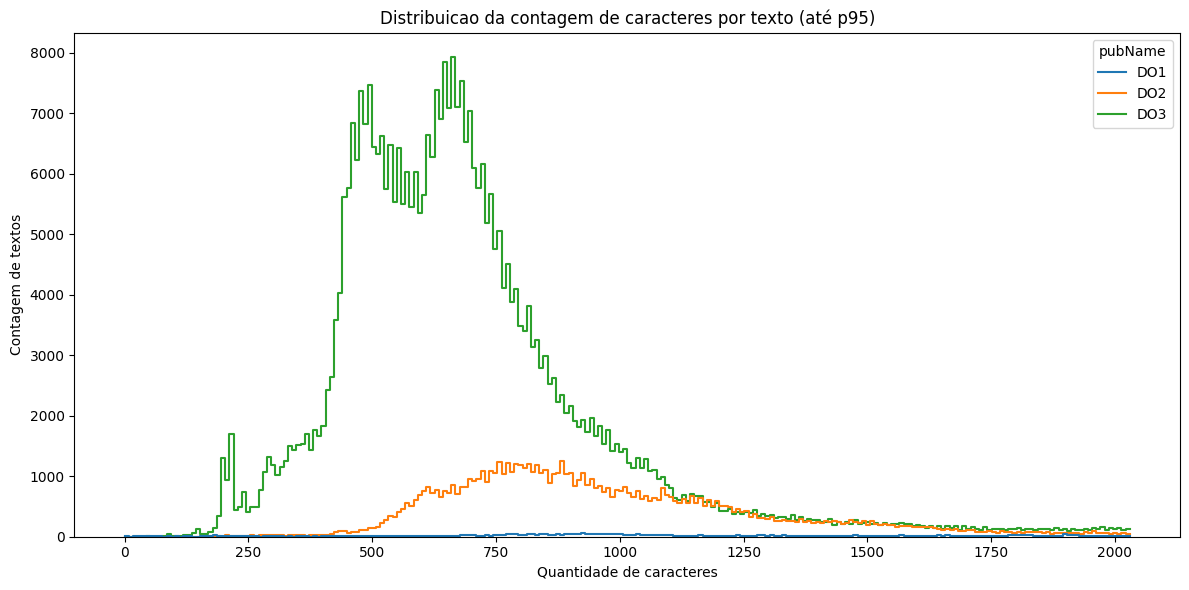

In [28]:
tamanho_por_publicacao = (
    df.select(
        pl.col("pubName").str.head(3).alias("pubName"),
        pl.col("texto").str.len_chars().alias("tamanho")
    )
    .drop_nulls("tamanho")
)

tamanho_pd = tamanho_por_publicacao.to_pandas()

limite_superior = tamanho_pd["tamanho"].quantile(0.95)
plot_data = tamanho_pd[tamanho_pd["tamanho"] <= limite_superior]

plt.figure(figsize=(12, 6))
sns.histplot(
    data=plot_data,
    x="tamanho",
    hue="pubName",
    bins=240,
    stat="count",
    common_norm=False,
    element="step",
    fill=False,
)
plt.title("Distribuicao da contagem de caracteres por texto (até p95)")
plt.xlabel("Quantidade de caracteres")
plt.ylabel("Contagem de textos")
plt.tight_layout()
plt.show()


In [29]:
tamanho_por_publicacao.describe()

statistic,pubName,tamanho
str,str,f64
"""count""","""511298""",511298.0
"""null_count""","""0""",0.0
"""mean""",null,1054.020919
"""std""",null,2631.051994
"""min""","""DO1""",0.0
"""25%""",null,547.0
"""50%""",null,696.0
"""75%""",null,915.0
"""max""","""DO3""",243728.0


In [30]:
df.filter(pl.col('texto').str.len_chars() == 0)

id,texto,pubName,name,artType,pubDate,artCategory,pdfPage
str,str,str,str,str,date,str,str
"""10695396""","""""","""DO1""","""BALANÇO PATRIMONIAL__170536""","""Balanço Patrimonial""",2018-04-23,"""Ministério da Defesa/Comando d…","""http://pesquisa.in.gov.br/impr…"
"""515_20190426_11640008""","""""","""DO1""","""BALANÇO PATRIMONIAL PDF""","""Balanço Patrimonial""",2019-04-26,"""Ministério da Defesa/Comando d…","""http://pesquisa.in.gov.br/impr…"
"""515_20230524_20621579-13.xml""","""""","""DO1""","""NORMAM-15-REV.3-MOD.3- EM EDIC…","""Portaria""",2023-05-24,"""Ministério da Defesa/Comando d…","""http://pesquisa.in.gov.br/impr…"
"""515_20240503_21587940-4""","""""","""DO1""","""NPCF CFB_4""","""Norma Complementar""",2024-05-03,"""Ministério da Defesa/Comando d…","""http://pesquisa.in.gov.br/impr…"


In [31]:
df.filter(pl.col('texto').str.len_chars() > 1e5).sort(pl.col('texto').str.len_chars(), descending=True).show(limit=-1)

id,texto,pubName,name,artType,pubDate,artCategory,pdfPage
str,str,str,str,str,date,str,str
"""515_20210825_13774871-2""","""INTRODUÇÃO 1 -PROPÓSITO Estabe…","""DO1""","""Port-23-2021-DPC-NORMAM-02_2__…","""Portaria""",2021-08-25,"""Ministério da Defesa/Comando d…","""http://pesquisa.in.gov.br/impr…"
"""515_20230919_20957231-9.xml""","""1.31. PETRECHOS PARA ATRAÇÃO E…","""DO1""","""PORT_103_2023_NORMAM-303_9__FG…","""Portaria""",2023-09-19,"""Ministério da Defesa/Comando d…","""http://pesquisa.in.gov.br/impr…"
"""530_20210819_13760714""","""EDITAL Nº 01, DE 09 DE MARÇO D…","""DO3""","""HomologaAAo DOU__BI4YBK""","""Resultado de Concurso Público""",2021-08-19,"""Ministério da Defesa/Comando d…","""http://pesquisa.in.gov.br/impr…"
"""529_20180830_11036998""","""PORTARIA Nº 16-D A PROM, de 22…","""DO2""","""port_promocao_ott_DOU__154231""","""Portaria""",2018-08-30,"""Ministério da Defesa/Comando d…","""http://pesquisa.in.gov.br/impr…"
"""529_20190830_11972965""","""PORTARIA Nº 10-D A PROM, DE 26…","""DO2""","""port_promocao_ott_DOU""","""Portaria""",2019-08-30,"""Ministério da Defesa/Comando d…","""http://pesquisa.in.gov.br/impr…"
"""529_20220901_19853024""","""PORTARIA-D A PROM/DGP/C Ex nº …","""DO2""","""port_promocao_Of TemporArio pa…","""Portaria""",2022-09-01,"""Ministério da Defesa/Comando d…","""http://pesquisa.in.gov.br/impr…"
"""530_20230427_20549237-1.xml""","""EDITAL DE 26 DE ABRIL DE 2023C…","""DO3""","""Edital - CP-QC-CA-FN-IM 2023_1""","""Edital de Concurso Público""",2023-04-27,"""Ministério da Defesa/Comando d…","""http://pesquisa.in.gov.br/impr…"
"""515_20250120_22312143-2""","""NORMAS DA AUTORIDADE MARÍTIMA …","""DO1""","""PORT-169-2025_NORMAM-101_002""","""Portaria""",2025-01-20,"""Ministério da Defesa/Comando d…","""http://pesquisa.in.gov.br/impr…"
"""515_20210830_13786684-3""","""OBSERVAÇÕES: - Os Oficiais de …","""DO1""","""Port-28-Alt-NORMAM-13_DOU_3""","""Portaria""",2021-08-30,"""Ministério da Defesa/Comando d…","""http://pesquisa.in.gov.br/impr…"


## Percentagem de textos duplicados ou quase duplicados


In [32]:
df.filter(df.select('texto').is_duplicated())

id,texto,pubName,name,artType,pubDate,artCategory,pdfPage
str,str,str,str,str,date,str,str
"""529_20200102_12324586""",""" PORTARIA Nº 2, DE 20 DE DEZE…","""DO2""","""Publicacao DOU nomeacao OD_TCE…","""Portaria""",2020-01-02,"""Ministério da Defesa/Comando d…","""http://pesquisa.in.gov.br/impr…"
"""529_20200102_12324586""",""" PORTARIA Nº 2, DE 20 DE DEZE…","""DO2""","""Publicacao DOU nomeacao OD_TCE…","""Portaria""",2020-01-02,"""Ministério da Defesa/Comando d…","""http://pesquisa.in.gov.br/impr…"
"""529_20200102_12326901""",""" PORTARIA Nº 1.178-DCIPAS/SPC,…","""DO2""","""PORT-1178-DCIPAS-JOGINALDO-APO…","""Portaria""",2020-01-02,"""Ministério da Defesa/Comando d…","""http://pesquisa.in.gov.br/impr…"
"""529_20200102_12326901""",""" PORTARIA Nº 1.178-DCIPAS/SPC,…","""DO2""","""PORT-1178-DCIPAS-JOGINALDO-APO…","""Portaria""",2020-01-02,"""Ministério da Defesa/Comando d…","""http://pesquisa.in.gov.br/impr…"
"""529_20200102_12326902""",""" PORTARIA Nº 1.218-DCIPAS/SPC,…","""DO2""","""PORT-1218-DCIPAS-ANDRÉVIVALDO-…","""Portaria""",2020-01-02,"""Ministério da Defesa/Comando d…","""http://pesquisa.in.gov.br/impr…"
…,…,…,…,…,…,…,…
"""530_20251224_23452028""","""EXTRATO DE TERMO ADITIVO Nº 4/…","""DO3""","""2025-12-23/11491399/COMPRASNET…","""Extrato de Termo Aditivo""",2025-12-24,"""Ministério da Defesa/Comando d…","""http://pesquisa.in.gov.br/impr…"
"""530_20251224_23453175""","""EXTRATO DE TERMO ADITIVO Nº 3/…","""DO3""","""2025-12-23/11492347/COMPRASNET…","""Retificação""",2025-12-24,"""Ministério da Defesa/Comando d…","""http://pesquisa.in.gov.br/impr…"
"""530_20251226_23456755""","""EXTRATO DE CREDENCIAMENTO Nº 1…","""DO3""","""2025-12-24/11494789/COMPRASNET…","""Extrato de Credenciamento""",2025-12-26,"""Ministério da Defesa/Comando d…","""http://pesquisa.in.gov.br/impr…"


## Percentual de textos vazios ou muito curtos

In [33]:
df.filter(pl.col('texto').str.len_chars() < 140).show(limit=20, fmt_str_lengths=150)

id,texto,pubName,name,artType,pubDate,artCategory,pdfPage
str,str,str,str,str,date,str,str
"""515_20240126_21349055-2""","""Leia-se:""","""DO1""","""RETIFICACAO_PORT_115_NORMAM_102_""","""Portaria""",2024-01-26,"""Ministério da Defesa/Comando da Marinha/Diretoria-Geral de Navegação/Diretoria de Portos e Costas""","""http://pesquisa.in.gov.br/imprensa/jsp/visualiza/index.jsp?data=26/01/2024&jornal=515&pagina=7"""
"""515_20240126_21349055-3""","""Nos anexos: Onde se lê:""","""DO1""","""RETIFICACAO_PORT_115_NORMAM_102_""","""Portaria""",2024-01-26,"""Ministério da Defesa/Comando da Marinha/Diretoria-Geral de Navegação/Diretoria de Portos e Costas""","""http://pesquisa.in.gov.br/imprensa/jsp/visualiza/index.jsp?data=26/01/2024&jornal=515&pagina=8"""
"""515_20240126_21349055-4""","""Leia-se:""","""DO1""","""RETIFICACAO_PORT_115_NORMAM_102_""","""Portaria""",2024-01-26,"""Ministério da Defesa/Comando da Marinha/Diretoria-Geral de Navegação/Diretoria de Portos e Costas""","""http://pesquisa.in.gov.br/imprensa/jsp/visualiza/index.jsp?data=26/01/2024&jornal=515&pagina=8"""
"""515_20240126_21349055-5""","""Onde se lê:""","""DO1""","""RETIFICACAO_PORT_115_NORMAM_102_""","""Portaria""",2024-01-26,"""Ministério da Defesa/Comando da Marinha/Diretoria-Geral de Navegação/Diretoria de Portos e Costas""","""http://pesquisa.in.gov.br/imprensa/jsp/visualiza/index.jsp?data=26/01/2024&jornal=515&pagina=8"""
"""515_20240126_21349055-6""","""Leia-se:""","""DO1""","""RETIFICACAO_PORT_115_NORMAM_102_""","""Portaria""",2024-01-26,"""Ministério da Defesa/Comando da Marinha/Diretoria-Geral de Navegação/Diretoria de Portos e Costas""","""http://pesquisa.in.gov.br/imprensa/jsp/visualiza/index.jsp?data=26/01/2024&jornal=515&pagina=8"""
"""515_20240126_21349055-7""","""Onde se lê:""","""DO1""","""RETIFICACAO_PORT_115_NORMAM_102_""","""Portaria""",2024-01-26,"""Ministério da Defesa/Comando da Marinha/Diretoria-Geral de Navegação/Diretoria de Portos e Costas""","""http://pesquisa.in.gov.br/imprensa/jsp/visualiza/index.jsp?data=26/01/2024&jornal=515&pagina=9"""
"""515_20240126_21349055-8""","""Leia-se:""","""DO1""","""RETIFICACAO_PORT_115_NORMAM_102_""","""Portaria""",2024-01-26,"""Ministério da Defesa/Comando da Marinha/Diretoria-Geral de Navegação/Diretoria de Portos e Costas""","""http://pesquisa.in.gov.br/imprensa/jsp/visualiza/index.jsp?data=26/01/2024&jornal=515&pagina=9"""
"""515_20250117_22310597-19""","""3.7.16 as bóias classes II e III deverão ser submetidas e aprovada nos seguintes testes:""","""DO1""","""Port-154-2025-DPC NORMAM-321 EDI""","""Portaria""",2025-01-17,"""Ministério da Defesa/Comando da Marinha/Diretoria-Geral de Navegação/Diretoria de Portos e Costas""","""http://pesquisa.in.gov.br/imprensa/jsp/visualiza/index.jsp?data=17/01/2025&jornal=515&pagina=71"""
"""515_20250117_22311209-5""","""1.15. CALADO AÉREO""","""DO1""","""PORT-157-NORMAM-303_005""","""Portaria""",2025-01-17,"""Ministério da Defesa/Comando da Marinha/Diretoria-Geral de Navegação/Diretoria de Portos e Costas""","""http://pesquisa.in.gov.br/imprensa/jsp/visualiza/index.jsp?data=17/01/2025&jornal=515&pagina=124"""


# 2. Qualidade e padronização textual

## Sinônimos com grafias diferentes

## Siglas não padronizadas

## Nomes próprios com múltiplas grafias

## Mudanças históricas de vocabulário

## Boilerplates (cabeçalhos e rodapés)

# 3. Descoberta de temas

## Assuntos dos textos

Pipeline:

Remover números -> remover stopwords -> lemmatize ou stem -> vetorizar com o tf idf -> tentar reduzir a dimensionalidade com PCA -> clusterizar os documentos pelos vetores obtidos

In [34]:
import os
import re
import threading
import numpy as np
import pandas as pd
import plotly.express as px

from concurrent.futures import ThreadPoolExecutor, as_completed

from IPython.display import display

import torch
from transformers import AutoTokenizer, AutoModel

from nltk.corpus import stopwords

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score



In [35]:
class TextClusterPipeline:
    def __init__(
        self,
        use_lemma=True,
        model_name='neuralmind/bert-base-portuguese-cased',
        batch_size=24,
        max_length=256,
        spacy_batch_size=256,
        k_min=2,
        k_max=12,
        max_pca_components=30,
        random_state=42,
    ):
        self.use_lemma = use_lemma
        self.model_name = model_name
        self.batch_size = batch_size
        self.max_length = max_length
        self.spacy_batch_size = spacy_batch_size
        self.k_min = k_min
        self.k_max = k_max
        self.max_pca_components = max_pca_components
        self.random_state = random_state

        self.stopwords_pt = self._carregar_stopwords()
        self.regex_limpeza = re.compile(r'[^a-zA-ZÀ-ÿ\s]')

        self.nlp_lemma, self.mensagem_lemma = self._carregar_modelo_lemma()
        self.usar_lemma = self.nlp_lemma is not None

        self.device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.mps.is_available() else 'cpu')
        self._hf_lock = threading.Lock()
        self.tokenizer, self.model = self._carregar_bertimbau()

    def _carregar_stopwords(self):
        fallback = {
            'a', 'o', 'os', 'as', 'de', 'da', 'do', 'das', 'dos',
            'e', 'em', 'para', 'por', 'com', 'um', 'uma', 'no', 'na', 'nos', 'nas',
            'que', 'se', 'ao', 'aos', 'à', 'às'
        }
        try:
            return set(stopwords.words('portuguese'))
        except LookupError:
            return fallback

    def _carregar_modelo_lemma(self):
        if not self.use_lemma:
            return None, 'Lemma desativado por configuração.'

        try:
            import spacy
        except Exception as exc:
            raise RuntimeError(f'spaCy não está disponível para lematização: {exc}')

        for nome_modelo in ['pt_core_news_lg', 'pt_core_news_md', 'pt_core_news_sm']:
            try:
                nlp = spacy.load(nome_modelo, disable=['ner', 'parser', 'textcat'])
                return nlp, f'Lemma habilitado via spaCy com o modelo {nome_modelo}.'
            except Exception:
                continue

        raise RuntimeError('Nenhum modelo spaCy PT encontrado para lematização.')

    def _carregar_bertimbau(self):
        model_kwargs = {}
        if self.device.type == 'cuda':
            model_kwargs['torch_dtype'] = torch.float16

        try:
            tokenizer = AutoTokenizer.from_pretrained(self.model_name)
            model = AutoModel.from_pretrained(self.model_name, **model_kwargs)
        except Exception as exc:
            raise RuntimeError(f'Falha ao carregar {self.model_name}: {exc}')

        model.to(self.device)
        model.eval()
        return tokenizer, model

    def _limpeza_basica_texto(self, texto):
        texto = str(texto).lower()
        texto = self.regex_limpeza.sub(' ', texto)
        tokens = [token for token in texto.split() if token not in self.stopwords_pt and len(token) > 1]
        return ' '.join(tokens)

    def _aplicar_lemma_em_lote(self, textos_limpos):
        docs = self.nlp_lemma.pipe(textos_limpos, batch_size=self.spacy_batch_size)
        textos_lemma = []

        for doc in docs:
            lemmas = [tok.lemma_.lower() for tok in doc if tok.lemma_ and not tok.is_space]
            textos_lemma.append(' '.join(lemmas))

        return textos_lemma

    def _preprocessar_textos_em_lote(self, textos):
        textos_limpos = [self._limpeza_basica_texto(t) for t in textos]

        if not self.usar_lemma:
            return textos_limpos

        # Otimização: lematiza somente textos únicos e depois remapeia.
        textos_unicos = list(dict.fromkeys(textos_limpos))
        textos_unicos_lemma = self._aplicar_lemma_em_lote(textos_unicos)
        mapa_lemma = dict(zip(textos_unicos, textos_unicos_lemma))

        return [mapa_lemma[t] for t in textos_limpos]

    @staticmethod
    def _mean_pooling(last_hidden_state, attention_mask):
        mask = attention_mask.unsqueeze(-1).expand(last_hidden_state.size()).float()
        soma = torch.sum(last_hidden_state * mask, dim=1)
        divisor = torch.clamp(mask.sum(dim=1), min=1e-9)
        return soma / divisor

    def _preparar_dataframe(self, df_entrada):
        df_work = df_entrada.copy()
        if 'pubName' not in df_work.columns:
            df_work['pubName'] = 'SEM_PUB'

        df_work['texto'] = df_work['texto'].fillna('')
        df_work['texto_processado'] = self._preprocessar_textos_em_lote(df_work['texto'].tolist())
        df_work = df_work[df_work['texto_processado'].str.len() > 0].reset_index(drop=True)

        if len(df_work) < 3:
            raise ValueError('Poucos documentos após limpeza (mínimo recomendado: 3).')

        return df_work

    def _gerar_embeddings_bert(self, textos_processados):
        textos = list(textos_processados)
        embeddings = []

        for inicio in range(0, len(textos), self.batch_size):
            lote = textos[inicio:inicio + self.batch_size]

            with self._hf_lock:
                inputs = self.tokenizer(
                    lote,
                    padding=True,
                    truncation=True,
                    max_length=self.max_length,
                    return_tensors='pt',
                )
                inputs = {chave: valor.to(self.device) for chave, valor in inputs.items()}

                with torch.inference_mode():
                    if self.device.type == 'cuda':
                        with torch.autocast(device_type='cuda', dtype=torch.float16):
                            outputs = self.model(**inputs)
                    else:
                        outputs = self.model(**inputs)

                lote_embeddings = self._mean_pooling(outputs.last_hidden_state, inputs['attention_mask'])
                embeddings.append(lote_embeddings.cpu().numpy().astype(np.float32))

        return np.vstack(embeddings)

    def _gerar_matrizes(self, textos_processados):
        x_embeddings = self._gerar_embeddings_bert(textos_processados)

        max_componentes_validos = min(x_embeddings.shape[0], x_embeddings.shape[1])
        if max_componentes_validos < 2:
            raise ValueError('Poucos termos para aplicar PCA e clusterização.')

        n_componentes_cluster = min(self.max_pca_components, max_componentes_validos)
        pca_cluster = PCA(n_components=n_componentes_cluster, random_state=self.random_state)
        x_cluster = pca_cluster.fit_transform(x_embeddings)

        pca_plot = PCA(n_components=2, random_state=self.random_state)
        x_plot = pca_plot.fit_transform(x_cluster)

        return x_cluster, x_plot

    def _escolher_k(self, x_cluster):
        k_max_real = min(self.k_max, len(x_cluster) - 1)
        if k_max_real < self.k_min:
            raise ValueError('Poucos documentos para testar múltiplos clusters.')

        avaliacoes = []
        for k in range(self.k_min, k_max_real + 1):
            modelo = KMeans(n_clusters=k, random_state=self.random_state, n_init='auto')
            labels = modelo.fit_predict(x_cluster)
            avaliacoes.append({
                'k': k,
                'inercia': modelo.inertia_,
                'silhouette': silhouette_score(x_cluster, labels),
            })

        avaliacao_clusters = pd.DataFrame(avaliacoes)
        melhor_k = int(avaliacao_clusters.loc[avaliacao_clusters['silhouette'].idxmax(), 'k'])
        return avaliacao_clusters, melhor_k

    def fit_transform(self, df_entrada, subset_name='dataset'):
        df_work = self._preparar_dataframe(df_entrada)
        x_cluster, x_plot = self._gerar_matrizes(df_work['texto_processado'])
        avaliacao_clusters, melhor_k = self._escolher_k(x_cluster)

        kmeans = KMeans(n_clusters=melhor_k, random_state=self.random_state, n_init='auto')
        clusters = kmeans.fit_predict(x_cluster)

        df_clusters = df_work[['id', 'pubName']].copy()
        df_clusters['cluster'] = clusters.astype(str)
        df_clusters['pca_1'] = x_plot[:, 0]
        df_clusters['pca_2'] = x_plot[:, 1]
        df_clusters['subset'] = subset_name

        return {
            'df_clusters': df_clusters,
            'avaliacao_clusters': avaliacao_clusters,
            'melhor_k': melhor_k,
            'normalizacao': 'lemma_spacy' if self.usar_lemma else 'sem_lemma',
            'mensagem_normalizacao': self.mensagem_lemma,
            'vetorizacao': 'bertimbau',
            'modelo_embedding': self.model_name,
            'device': str(self.device),
        }



In [36]:
pubs_alvo = ['DO1', 'DO2', 'DO3']
datasets_por_pub = {}

for pub in pubs_alvo:
    df_pub = (
        df
        .filter(pl.col('pubName').str.head(3) == pub)
        .select('id', 'texto', 'pubName')
        .to_pandas()
    )
    if len(df_pub) > 0:
        datasets_por_pub[pub] = df_pub

print(f'Datasets preparados: {list(datasets_por_pub.keys())}')


Datasets preparados: ['DO1', 'DO2', 'DO3']


In [37]:
pipeline_compartilhado = TextClusterPipeline(
    use_lemma=True,
    model_name='neuralmind/bert-base-portuguese-cased',
    batch_size=24,
    max_length=256,
    spacy_batch_size=256,
)

print(f'Dispositivo do pipeline: {pipeline_compartilhado.device}')
print(pipeline_compartilhado.mensagem_lemma)


def executar_pipeline(item):
    pub, df_pub = item

    try:
        resultado = pipeline_compartilhado.fit_transform(df_pub, subset_name=pub)
        return {
            'pub': pub,
            'ok': True,
            'resultado': resultado,
            'erro': None,
        }
    except Exception as exc:
        return {
            'pub': pub,
            'ok': False,
            'resultado': None,
            'erro': str(exc),
        }


def criar_barra_progresso(total):
    try:
        from ipywidgets import IntProgress, HTML, VBox

        barra = IntProgress(value=0, min=0, max=total, description='Pipeline:')
        status = HTML(value=f'0/{total} concluídos')
        display(VBox([barra, status]))

        def atualizar(pub):
            barra.value += 1
            status.value = f'{barra.value}/{total} concluídos | último: {pub}'

        return atualizar
    except Exception:
        contador = {'valor': 0}

        def atualizar(pub):
            contador['valor'] += 1
            print(f"[{contador['valor']}/{total}] concluído: {pub}")

        return atualizar


resultados_por_pub = {}
falhas = []

if len(datasets_por_pub) == 0:
    raise ValueError('Nenhum dataset encontrado para as publicações selecionadas.')

workers_configurados = max(8, os.cpu_count() or 1)
max_workers = min(workers_configurados, len(datasets_por_pub))
print(f'Executando com {max_workers} worker(s).')

atualizar_progresso = criar_barra_progresso(total=len(datasets_por_pub))

with ThreadPoolExecutor(max_workers=max_workers) as executor:
    futures = [executor.submit(executar_pipeline, item) for item in datasets_por_pub.items()]
    for future in as_completed(futures):
        retorno = future.result()
        atualizar_progresso(retorno['pub'])

        if retorno['ok']:
            resultados_por_pub[retorno['pub']] = retorno['resultado']
        else:
            falhas.append({'pub': retorno['pub'], 'erro': retorno['erro']})

if len(resultados_por_pub) == 0:
    raise ValueError('Todos os subconjuntos falharam no pipeline. Verifique a variável falhas.')

resumo_execucao = []
for pub, resultado in resultados_por_pub.items():
    resumo_execucao.append({
        'pubName': pub,
        'documentos': len(resultado['df_clusters']),
        'melhor_k': resultado['melhor_k'],
        'normalizacao': resultado['normalizacao'],
        'detalhe_normalizacao': resultado['mensagem_normalizacao'],
        'vetorizacao': resultado['vetorizacao'],
        'modelo_embedding': resultado['modelo_embedding'],
        'device': resultado['device'],
    })

resumo_execucao = pd.DataFrame(resumo_execucao).sort_values('pubName')
resumo_execucao



RuntimeError: Nenhum modelo spaCy PT encontrado para lematização.

In [ ]:
if len(falhas) > 0:
    print('Falhas encontradas:')
    display(pd.DataFrame(falhas))

df_clusters = pd.concat(
    [resultado['df_clusters'] for resultado in resultados_por_pub.values()],
    ignore_index=True
)

df_clusters['cluster_pub'] = df_clusters['subset'] + '_C' + df_clusters['cluster']

fig = px.scatter(
    df_clusters,
    x='pca_1',
    y='pca_2',
    color='cluster_pub',
    facet_col='subset',
    hover_data=['id', 'pubName'],
    opacity=0.75,
    title='Clusters por publicação (execução paralela por pubName)'
)
fig.for_each_annotation(lambda a: a.update(text=a.text.replace('subset=', '')))
fig.show()

df_clusters.head()


In [ ]:
avaliacoes_lista = [
    resultado['avaliacao_clusters'].assign(pubName=pub)
    for pub, resultado in resultados_por_pub.items()
]

if len(avaliacoes_lista) == 0:
    raise ValueError('Sem avaliações de cluster para consolidar.')

avaliacoes_por_pub = pd.concat(avaliacoes_lista, ignore_index=True)

fig_metricas = px.line(
    avaliacoes_por_pub,
    x='k',
    y='silhouette',
    color='pubName',
    markers=True,
    title='Silhouette por pubName para escolha de k'
)
fig_metricas.show()

avaliacoes_por_pub.head()


In [ ]:
df_clusters['cluster_pub'].value_counts().sort_index()

In [ ]:
df_clusters[['id', 'pubName', 'subset', 'cluster', 'cluster_pub']].head()


In [ ]:
df_classificado = (
    df.join(pl.DataFrame(df_clusters).select('id', 'cluster'), on='id')
    .with_columns(
        pl.col('pubName').str.head(3),
        forca=pl.col('artCategory').str.extract(r'[Cc]omando d[ao] ([Mm]arinha|[Ee]x[ée]rcito|[Aa]eron[áa]utica)')
    )
    .drop_nulls()
    .group_by('pubName', 'artType', 'cluster', 'forca')
    .agg(pl.len())
)

In [ ]:
df_classificado.head()

In [ ]:
df_classificado.describe()

In [ ]:
fig = px.sunburst(df_classificado, path=['cluster', 'pubName', 'artType', 'forca'], values='len')
fig.show()

## Temas que dominam o acervo


## Mudança dos temas ao longo do tempo


## Temas exclusivos a certas organizações

# 4. Entidades e relações

## Pessoas

## Organizações


## Localidades


## Cargos


## Valores monetários

## Datas


## Objetos contratuais

## Normas e referências legais

# 5. Evolução temporal

## Variações de frequências de termos

## Eventos que alteram o vocabulário institucional

## Mudança do estilo redacional

## Temas cíclicos


# 6. Padrões de linguagem

## Textos formais ou padronizados


## Verbosidade dos documentos

## Uso de e linguagem técnica administrativa

## Níveis de repetição

## Densidade de termos jurídicos, financeiros ou operacionais

# 7. Anomalias e casos raros

## Documentos com vocabulário muito incomum

## Entidades que aparecem poucas vezes, porém em textos relevantes

## Textos que podem pertencer à classe errada

## Mudanças abruptas de temas em determinados períodos

## Contratos, decisões ou atos com redação única

# 8. Classificação e taxonomia

## Tema principal

## Subtipo documental

## Área funcional

## Natureza do ato

## Tipo de decisão

## Impacto institucional

# 9. Indicadores derivados de texto

## Índice de complexidade textual

## Índice de repetição

## Proporção de termos de contratação, pessoal, norma, logística

## Quantidade de entidades por documento

## Densidade de valores monetários por documento

## Presença de termos chave como urgência, dispensa, nomeação, exoneração, aquisição

# 10. Perguntas do KDD

## Quais são os grandes blocos temáticos do acervo?

## Como esses blocos temáticos tem mudado ao longo dos anos?

## Quais entidades mais aparecem e em quais contextos?

## Existem padrões distintos entre grupos, fontes ou instituições?

## Quais documentos fogem ao padrão esperado?

## Quais termos indicam muidanças de política, prioridade ou atividade?

## Que relações entre entidades são recorrentes?

## Quais temas estão crescendo ou desaparecendo?

## Quais documentos são altamente similares entre si?

## Há sinais de mudanças de linguagem institucional ao longo dos anos?